# Gibrán Leonardo Chávez González
## Exp: 757366
### Fecha: 26/03/26

In [1]:
from sklearn.neural_network import MLPClassifier
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

In [2]:
df = pd.read_csv('Heart Prediction Quantum Dataset.csv')
df.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1


In [3]:
del df['QuantumPatternFeature']

Hacer un EDA de nuestro dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            500 non-null    int64
 1   Gender         500 non-null    int64
 2   BloodPressure  500 non-null    int64
 3   Cholesterol    500 non-null    int64
 4   HeartRate      500 non-null    int64
 5   HeartDisease   500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


In [5]:
df.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,1.000000


Ver distribución de la edad

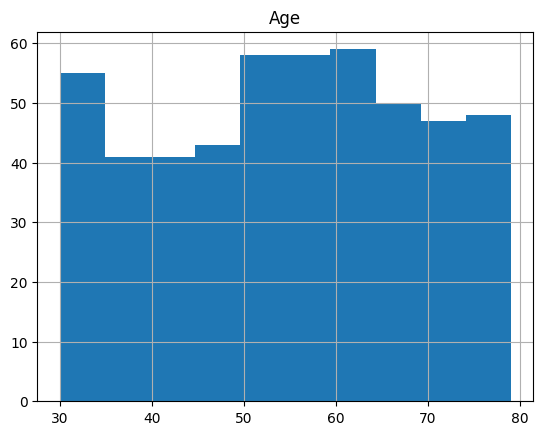

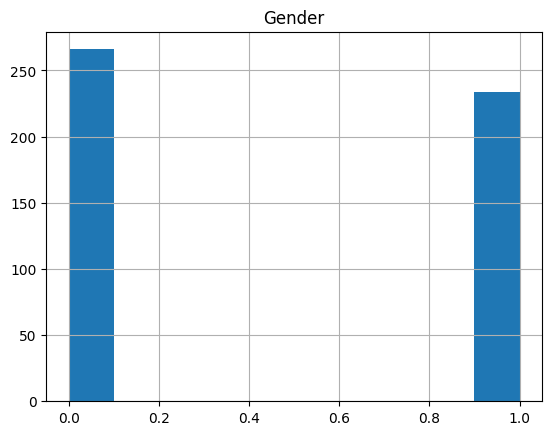

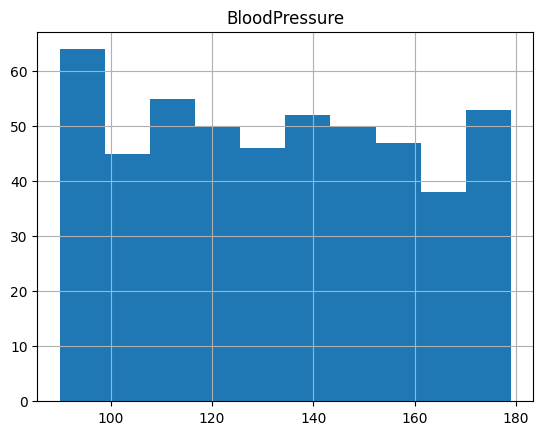

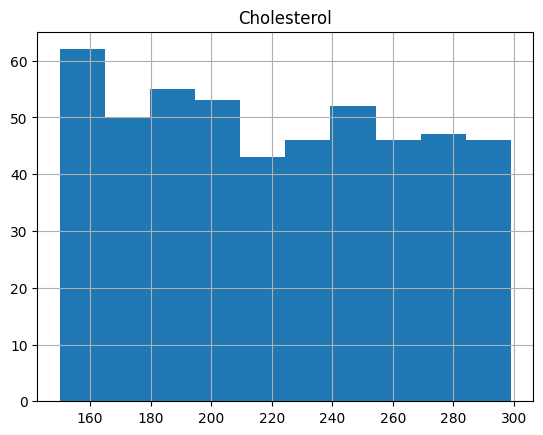

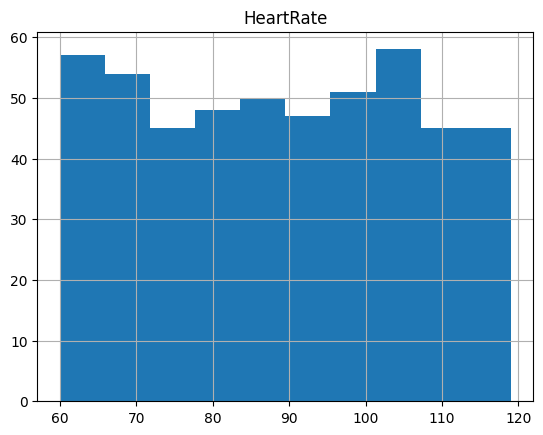

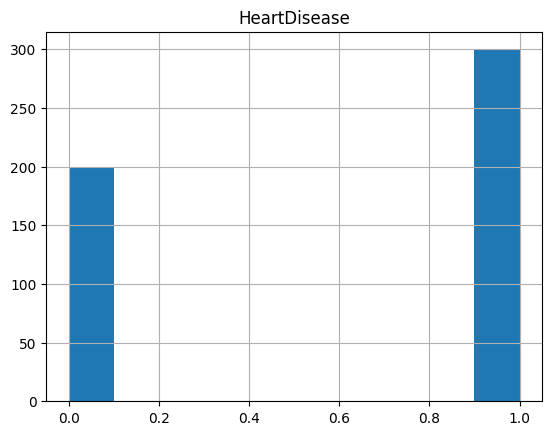

In [6]:
for column in df.columns:
    plt.title(f'{column}')
    df[column].hist()
    plt.show()

Pipeline

In [7]:
df.columns

Index(['Age', 'Gender', 'BloodPressure', 'Cholesterol', 'HeartRate',
       'HeartDisease'],
      dtype='object')

Definir X y y

In [8]:
X = df.drop(['HeartDisease'], axis=1)
X

,Age,Gender,BloodPressure,Cholesterol,HeartRate
0,68,1,105,191,107
1,58,0,97,249,89
2,44,0,93,190,82
3,72,1,93,183,101
4,37,0,145,166,103
...,...,...,...,...,...
495,34,0,126,292,116
496,41,0,164,248,114
497,45,1,159,175,75
498,55,0,107,157,101


In [9]:
y = df['HeartDisease']
y

0      1
1      0
2      1
3      1
4      1
      ..
495    0
496    0
497    0
498    1
499    0
Name: HeartDisease, Length: 500, dtype: int64

Tipos de variables

In [10]:
num_cols = ['Age', 'BloodPressure', 'Cholesterol', 'HeartRate']
cat_cols = ['Gender']

Escalamiento

In [11]:
num_transformer = StandardScaler()

Modelo


In [12]:
model = MLPClassifier(hidden_layer_sizes=[5, 10], random_state=42)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[('num', num_transformer, num_cols), # Etiquetra, tipo de transformación, a qué se lo aplicas
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Etiqueta, proceso
    ('model', model)]
)

In [14]:
pipeline.fit(X, y)

C:\Users\gibra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Accuracy

In [15]:
pipeline.score(X, y)

0.778

Cross validation con AUC

In [16]:
cross_val_score(pipeline, X, y, scoring='roc_auc_ovr', cv=10)

C:\Users\gibra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\gibra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\gibra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\gibra\A

array([0.84833333, 0.86666667, 0.76666667, 0.855     , 0.64666667,
       0.88666667, 0.87333333, 0.81833333, 0.855     , 0.87333333])

In [17]:
cross_val_score(pipeline, X, y, scoring='roc_auc_ovo', cv=10)

C:\Users\gibra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\gibra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\gibra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\gibra\A

array([0.84833333, 0.86666667, 0.76666667, 0.855     , 0.64666667,
       0.88666667, 0.87333333, 0.81833333, 0.855     , 0.87333333])

Optimización bayesiana para encontrar la mejor arquitectura de red neuronal

In [18]:
def evaluar_mlp(n1, n2, n3):
    'Esta función evalua una arquitectura de MLP de 3 capas y devuelve el "roc_auc_ovo" promedio'
    model = MLPClassifier(
        hidden_layer_sizes=(int(n1), int(n2), int(n3)),
        max_iter=2000,
        random_state=42
    )
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    score = cross_val_score(pipeline, X, y, scoring='roc_auc_ovo', cv=10).mean()
    
    return score


In [19]:
candidatos = []
# Iterar sobre todas las combinaciones posibles de neuronas en las 3 capas
for i in range(2, 7):      
    for j in range(5, 16): 
        for k in range(3, 7): 
            candidatos.append([i, j, k])

candidatos = np.array(candidatos)

In [20]:
np.random.seed(42)

n_iniciales = 5
indices_iniciales = np.random.choice(len(candidatos), size=n_iniciales, replace=False)

X_eval = candidatos[indices_iniciales]
y_eval = []

print("Evaluando puntos iniciales...\n")
for punto in X_eval:
    score = evaluar_mlp(punto[0], punto[1], punto[2])
    y_eval.append(score)
    print(f"Capas {tuple(punto)} -> roc_auc_ovo = {score:.6f}")

y_eval = np.array(y_eval)

Evaluando puntos iniciales...

Capas (np.int64(5), np.int64(5), np.int64(3)) -> roc_auc_ovo = 0.836417
Capas (np.int64(5), np.int64(9), np.int64(3)) -> roc_auc_ovo = 0.840000
Capas (np.int64(4), np.int64(6), np.int64(4)) -> roc_auc_ovo = 0.821750
Capas (np.int64(6), np.int64(6), np.int64(3)) -> roc_auc_ovo = 0.827750
Capas (np.int64(2), np.int64(8), np.int64(6)) -> roc_auc_ovo = 0.845833


In [21]:
kernel = 1.0 * RBF(length_scale=1.0)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)

In [22]:
hist_best = []

for t in range(30):
    gp.fit(X_eval, y_eval)
    
    # Filtrar candidatos no evaluados
    no_evaluados = []
    for punto in candidatos:
        ya_existe = False
        for punto_eval in X_eval:
            if np.array_equal(punto, punto_eval):
                ya_existe = True
                break
        if not ya_existe:
            no_evaluados.append(punto)
    
    no_evaluados = np.array(no_evaluados)
    
    if len(no_evaluados) == 0:
        print("\nYa se evaluaron todos los candidatos.")
        break
    

    y_pred, sigma = gp.predict(no_evaluados, return_std=True)
    
    y_upper = y_pred + 2 * sigma
    
    idx_best = np.argmax(y_upper)
    siguiente_punto = no_evaluados[idx_best]
    
    # Evaluar punto elegido
    siguiente_score = evaluar_mlp(
        siguiente_punto[0],
        siguiente_punto[1],
        siguiente_punto[2]
    )
    
    # Guardar
    X_eval = np.vstack([X_eval, siguiente_punto])
    y_eval = np.append(y_eval, siguiente_score)
    
    mejor_idx_actual = np.argmax(y_eval)
    mejor_config_actual = X_eval[mejor_idx_actual]
    mejor_score_actual = y_eval[mejor_idx_actual]
    hist_best.append(mejor_score_actual)
    
    print(f"\nIteración {t+1}")
    print(f"Punto sugerido por BO: {tuple(siguiente_punto)}")
    print(f"roc_auc_ovo obtenido: {siguiente_score:.6f}")
    print(f"Mejor hasta ahora: {tuple(mejor_config_actual)} -> {mejor_score_actual:.6f}")


Iteración 1
Punto sugerido por BO: (np.int64(2), np.int64(15), np.int64(6))
roc_auc_ovo obtenido: 0.845583
Mejor hasta ahora: (np.int64(2), np.int64(8), np.int64(6)) -> 0.845833

Iteración 2
Punto sugerido por BO: (np.int64(2), np.int64(12), np.int64(3))
roc_auc_ovo obtenido: 0.818750
Mejor hasta ahora: (np.int64(2), np.int64(8), np.int64(6)) -> 0.845833

Iteración 3
Punto sugerido por BO: (np.int64(6), np.int64(15), np.int64(3))
roc_auc_ovo obtenido: 0.849167
Mejor hasta ahora: (np.int64(6), np.int64(15), np.int64(3)) -> 0.849167

Iteración 4
Punto sugerido por BO: (np.int64(6), np.int64(15), np.int64(6))
roc_auc_ovo obtenido: 0.838000
Mejor hasta ahora: (np.int64(6), np.int64(15), np.int64(3)) -> 0.849167

Iteración 5
Punto sugerido por BO: (np.int64(2), np.int64(5), np.int64(3))
roc_auc_ovo obtenido: 0.823417
Mejor hasta ahora: (np.int64(6), np.int64(15), np.int64(3)) -> 0.849167

Iteración 6
Punto sugerido por BO: (np.int64(2), np.int64(12), np.int64(6))
roc_auc_ovo obtenido: 0.83

In [23]:
idx_final = np.argmax(y_eval)
mejor_arquitectura = X_eval[idx_final]
mejor_score = y_eval[idx_final]


print("MEJOR ARQUITECTURA ENCONTRADA")
print(f"Primera capa : {mejor_arquitectura[0]}")
print(f"Segunda capa : {mejor_arquitectura[1]}")
print(f"Tercera capa : {mejor_arquitectura[2]}")
print(f"Mejor roc_auc_ovo : {mejor_score:.6f}")


resultados = pd.DataFrame(X_eval, columns=['Capa_1', 'Capa_2', 'Capa_3'])
resultados['roc_auc_ovo'] = y_eval
resultados = resultados.sort_values(by='roc_auc_ovo', ascending=False).reset_index(drop=True)
resultados

MEJOR ARQUITECTURA ENCONTRADA
Primera capa : 5
Segunda capa : 5
Tercera capa : 6
Mejor roc_auc_ovo : 0.855000

Top 10 configuraciones evaluadas:


,Capa_1,Capa_2,Capa_3,roc_auc_ovo
0,5,5,6,0.855000
1,6,15,3,0.849167
2,6,5,6,0.846167
3,2,8,6,0.845833
4,2,15,6,0.845583
5,6,10,6,0.845000
6,2,5,6,0.844750
7,4,13,4,0.844500
8,2,10,6,0.843667
9,5,9,3,0.840000
